# 24RB1003 松澤颯斗

# 演習：決定木の実装

### データの生成

In [23]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# データ数 300, ノイズ 0.3 のデータを生成
X, y = make_moons(n_samples=300, noise=0.3, random_state=0)

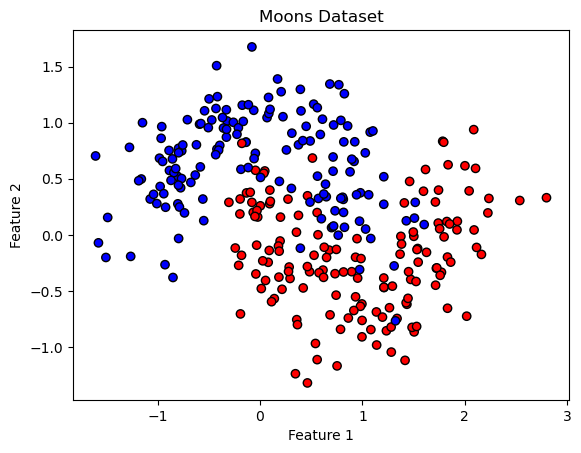

In [25]:
# データを散布図で表示
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1') 
plt.ylabel('Feature 2')
plt.title('Moons Dataset')
plt.show()

### モデルの学習

In [26]:
from decision_tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=3, criterion="gini")
clf.fit(X, y)
pred = clf.predict(X)

### 可視化

In [27]:
# グラフの描画範囲の決定
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# 細かい網目（グリッド）の作成
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# グリッド上のすべての座標を (サンプル数, 2) の二次元配列にまとめる
grid_points = np.c_[xx.ravel(), yy.ravel()]

In [28]:
# グリッド上の各点に対して予測を行い，Z に代入
Z = clf.predict(grid_points)
Z = Z.reshape(xx.shape)

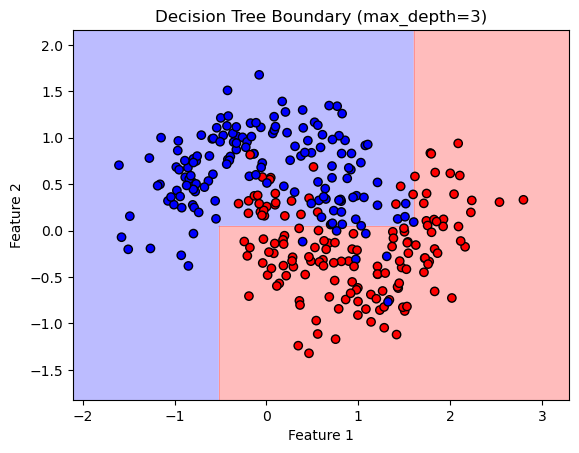

In [29]:
# グリッドの作成と予測
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# 予測とreshape
Z = clf.predict(grid_points)
Z = Z.reshape(xx.shape)

# 背景の決定境界を塗りつぶし (alphaで少し透明にして見やすくします)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')

# 元のデータポイント（散布図）を重ねて描画
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Boundary (max_depth=3)')
plt.show()

##### `max_depth`を変えて境界を確認

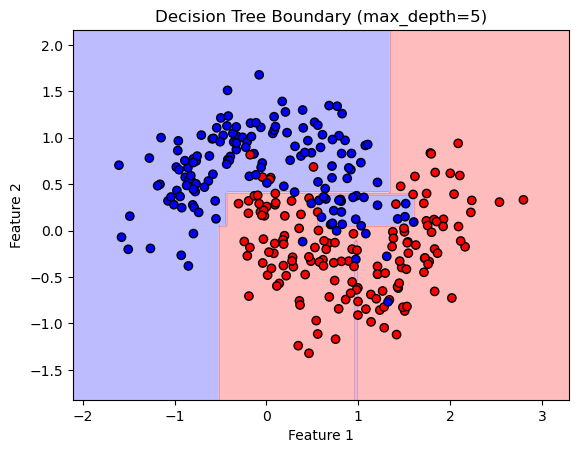

In [30]:
# max_depth=5 の決定木
clf_depth5 = DecisionTreeClassifier(max_depth=5, criterion="gini")
clf_depth5.fit(X, y)

Z_depth5 = clf_depth5.predict(grid_points)
Z_depth5 = Z_depth5.reshape(xx.shape)

plt.contourf(xx, yy, Z_depth5, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Boundary (max_depth=5)')
plt.show()

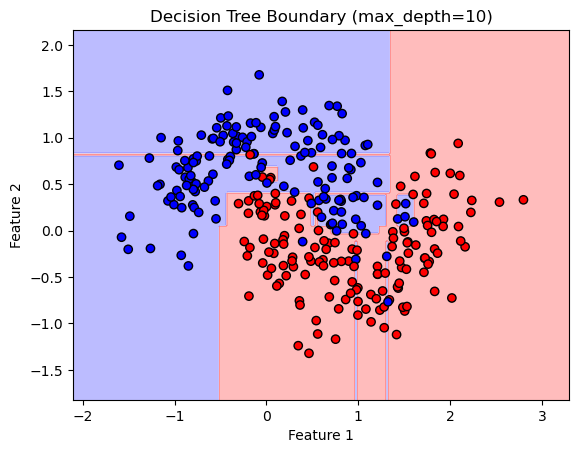

In [31]:
# max_depth=10 の決定木
clf_depth10 = DecisionTreeClassifier(max_depth=10, criterion="gini")
clf_depth10.fit(X, y)

Z_depth10 = clf_depth10.predict(grid_points)
Z_depth10 = Z_depth10.reshape(xx.shape)

plt.contourf(xx, yy, Z_depth10, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Boundary (max_depth=10)')
plt.show()

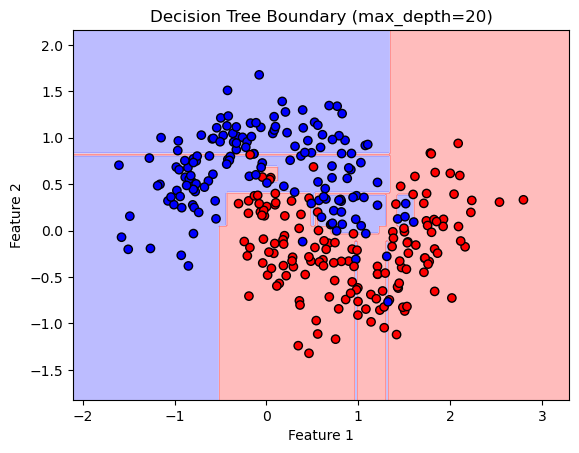

In [32]:
# max_depth=20 の決定木
clf_depth20 = DecisionTreeClassifier(max_depth=20, criterion="gini")
clf_depth20.fit(X, y)

Z_depth20 = clf_depth20.predict(grid_points)
Z_depth20 = Z_depth20.reshape(xx.shape)

plt.contourf(xx, yy, Z_depth20, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Boundary (max_depth=20)')
plt.show()

* `max_depth=3`の時は，大まかな段階上の線で全体をざっくりと分けている
* `max_depth=10`や`20`の時は，境界線が複雑に細かく入り込んでいる  

特に `max_depth=20` の左上のほうを見ると，青い陣地の中にポツンと紛れ込んだ1つの赤い点のために，わざわざ細長い赤い道を切り拓いてまで完璧に分類しようとしている．過学習が起きていることが分かる．

# 発展課題

### `sklearn.tree.DecisionTreeClassifier` の結果と比較

In [33]:
from sklearn.tree import DecisionTreeClassifier as SklearnDTC
sklearn_clf = SklearnDTC(max_depth=3, criterion="gini", random_state=0)
sklearn_clf.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

Text(0.5, 1.0, 'Sklearn Decision Tree Boundary (max_depth=3)')

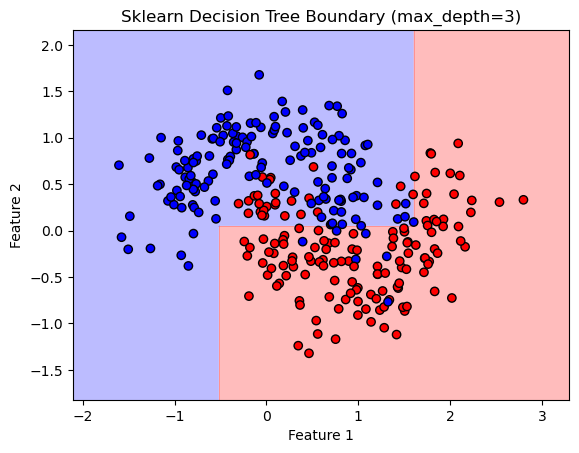

In [34]:
# 可視化
Z_sklearn = sklearn_clf.predict(grid_points)
Z_sklearn = Z_sklearn.reshape(xx.shape)

plt.contourf(xx, yy, Z_sklearn, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Sklearn Decision Tree Boundary (max_depth=3)')

結果を比較すると，データの分割位置や，赤と青のクラス領域の塗り分け方が完全に一致していた．このことから，自作した決定木クラスが不純度の計算や最適な分割条件の探索において，scikit-learn の実装と同等の機能を示していることが分かった．

### max_depth を変えて訓練誤差・テスト誤差をプロット（過学習の確認）

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

clf = DecisionTreeClassifier(max_depth=3, criterion="gini")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 精度を計算
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8833333333333333

In [36]:
train_errors = [] # 訓練誤差を保存するリスト
test_errors = []  # テスト誤差を保存するリスト

# max_depth を 1 から 15 まで変化させてループ
for depth in range(1, 16):
    # 1.モデルの準備
    clf = DecisionTreeClassifier(max_depth=depth, criterion="gini")

    # 2. X_train, y_train で学習
    clf.fit(X_train, y_train)
    
    # 3. trainデータとtestデータそれぞれに対する予測を行う
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    
    # 誤差の計算と保存 
    train_error = 1.0 - accuracy_score(y_train, y_train_pred)
    test_error = 1.0 - accuracy_score(y_test, y_test_pred)
    
    train_errors.append(train_error)
    test_errors.append(test_error)

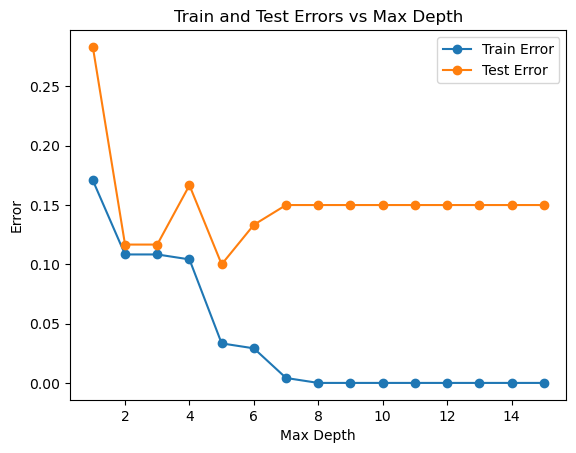

In [37]:
# 可視化
plt.plot(range(1, 16), train_errors, label='Train Error', marker='o')
plt.plot(range(1, 16), test_errors, label='Test Error', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Error')
plt.title('Train and Test Errors vs Max Depth')
plt.legend()
plt.show()

* `max_depth=4`以降からテスト誤差が上昇に転じたり不安定になる一方で，訓練誤差は下がり続けている．
* `max_depth=7`以降になると，訓練誤差は 0.00 に到達して変化しなくなるが，テスト誤差は 0.15 付近で高いまま下げ止まっている．

決定木の深さを制限しないと，学習データを完全に暗記してしまい，過学習が発生することが確認できた．2つの誤差の乖離が始まる直前の 深さ2または3 が，このデータセットに対して最も汎化性能が高いパラメータ設定であると推測される．

### 不純度関数を Gini とエントロピーで切り替え，結果に差が出るか比較

In [38]:
gini_test_errors = []    # Giniのテスト誤差用
entropy_test_errors = [] # エントロピーのテスト誤差用

for depth in range(1, 16):
    # Giniの処理 
    clf_gini = DecisionTreeClassifier(max_depth=depth, criterion="gini")
    clf_gini.fit(X_train, y_train)
    y_test_pred_gini = clf_gini.predict(X_test)
    gini_test_errors.append(1.0 - accuracy_score(y_test, y_test_pred_gini))
    
    # エントロピーの処理 
    clf_entropy = DecisionTreeClassifier(max_depth=depth, criterion="entropy")
    clf_entropy.fit(X_train, y_train)
    y_test_pred_entropy = clf_entropy.predict(X_test)
    entropy_test_errors.append(1.0 - accuracy_score(y_test, y_test_pred_entropy))

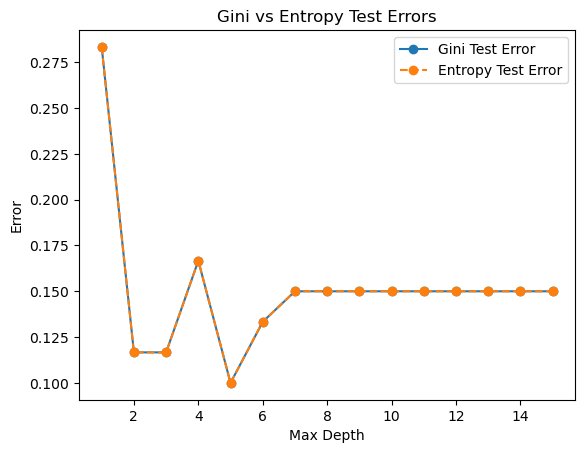

In [39]:
# 可視化
plt.plot(range(1, 16), gini_test_errors, label='Gini Test Error', marker='o')
plt.plot(range(1, 16), entropy_test_errors, label='Entropy Test Error', marker='o', linestyle='--')
plt.xlabel('Max Depth')
plt.ylabel('Error')
plt.title('Gini vs Entropy Test Errors')
plt.legend()
plt.show()

不純度関数を Gini とエントロピーで切り替え，それぞれ木の深さを1〜15まで変化させたときのテスト誤差をグラフに描画して比較したところ，すべての深さにおいて Giniを用いたモデルとエントロピーを用いたモデルのテスト誤差が一致した．結果に差が出なかった．

# 考察

決定木において，木の最大の深さを誤差の推移を確認したところ，木を深くするほど訓練誤差は0へと近づく一方で，テスト誤差は一定の高い値で下げ止まり，過学習の発生が確認できた．
今回のデータセットにおいて汎化性能を最大化するためには，過学習が進行する前の深さ2から3程度で木の成長を止めるのが最適であると考えられる．
さらに，分割の評価基準としてGini不純度とエントロピーを切り替えてテスト誤差を比較した結果，すべての深さにおいて両者の推移は完全に一致した．
これは，両者がデータの混ざり具合を測る指標として近い性質を持っており，今回のようなシンプルなデータセットにおいては，どちらを使用してもモデルの学習プロセスや最終的な木の構造に差異が生じないためであると考えられる．

# AI使用について

Gemini Guided Learningを使用して，decision_tree.pyのメソッドの役割や実装方法，また可視化の方法について質問した．AI に直接コードを生成させることはせず，実装の方針や考え方のヒントのみをもらい，それをもとに自身でコードを作成した．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．